# Preparation for Lab 2 from Group 1 (Wörner, Velez, Northe)

The source code and the binaries from this report can be found in our Github [repository](https://github.com/NortheLo/Microwave_Eng_Lab/tree/main/Lab1_Network_Analysis).

In [503]:
import numpy as np
from numpy.typing import NDArray
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

In [504]:
lin2db = lambda g: 10 * np.log10(g)

assert 20 == lin2db(100)

In [505]:
def plot_spectrum(freq: NDArray, amplitude: NDArray,
                          title: str = "Frequency Spectrum",
                          markers: list[dict] = None,
                          db_scale: bool = False,
                          xlim: tuple = None,
                          freq_unit: str = "MHz",
                          freq_scale: float = 1e6):
    """
    Plot frequency spectrum with optional markers and scaling.
    
    Parameters:
    -----------
    freq : NDArray
        Frequency array (in Hz)
    amplitude : NDArray
        Amplitude array
    title : str
        Plot title
    markers : list[dict]
        List of marker dictionaries with keys: 'position', 'name', 'color'
    db_scale : bool
        If True, convert amplitude to dB scale
    xlim : tuple
        Frequency limits for x-axis (in Hz)
    freq_unit : str
        Unit label for frequency axis
    freq_scale : float
        Scaling factor for frequency axis (e.g., 1e6 for MHz)
    """
    
    plot_amplitude = lin2db(amplitude) if db_scale else amplitude
    
    # Create plot
    plt.figure(figsize=(12, 5))
    plt.plot(freq / freq_scale, plot_amplitude, label="Spectrum", linewidth=1.5)
    plt.xlabel(f"Frequency ({freq_unit})")
    plt.ylabel("Amplitude [dB]" if db_scale else "Amplitude [lin]")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    
    # Add markers if provided
    if markers:
        for marker in markers:
            # Find closest frequency index
            idx = np.argmin(np.abs(freq - marker['position']))
            plt.plot(freq[idx] / freq_scale, plot_amplitude[idx], 'o', 
                    color=marker['color'], 
                    markersize=8, 
                    markeredgecolor='black', 
                    markeredgewidth=1,
                    label=marker['name'])
    
    # Set x-axis limits if provided
    if xlim:
        plt.xlim(xlim[0] / freq_scale, xlim[1] / freq_scale)
    
    plt.legend()
    plt.tight_layout()
    plt.show()

In [506]:
def plot_time_domain(time: NDArray, 
                    signals: list[dict],
                    time_unit: str = "μs",
                    time_scale: float = 1e6,
                    figsize: tuple = (12, 6),
                    title: str = "Time Domain Signals"):
    """
    Plot multiple time domain signals in subplots.
    
    Parameters:
    -----------
    time : NDArray
        Time array (in seconds)
    signals : list[dict]
        List of signal dictionaries with keys: 'data', 'label', 'color', 'title'
    time_unit : str
        Unit label for time axis
    time_scale : float
        Scaling factor for time axis (e.g., 1e6 for μs)
    figsize : tuple
        Figure size (width, height)
    title : str
        Overall title for the figure
    """
    
    n_signals = len(signals)
    
    plt.figure(figsize=figsize)
    
    for i, signal in enumerate(signals):
        plt.subplot(n_signals, 1, i + 1)
        plt.plot(time * time_scale, signal['data'], 
                label=signal['label'], 
                color=signal.get('color', 'blue'))
        plt.xlabel(f"Time ({time_unit})")
        plt.ylabel("Amplitude")
        plt.title(signal.get('title', f"Signal {i+1}"))
        plt.grid(True, alpha=0.3)
        plt.legend()
    
    plt.suptitle(title, fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()

**Simulation time step frequency** 

In [507]:
f_s = 100e9     # [Hz]

## Task 1: AM-Signal

In [508]:
f_c = 2e9       # [Hz]
f_m = 1e6       # [Hz]

t_max = 3e-6
t = np.arange(0, t_max, 1/f_s)
m = 2.1 * np.cos(2 * np.pi * f_m * t) + 3

In [509]:
s_c = np.cos(2 * np.pi * f_c * t)
s_bp = np.multiply(m, s_c)

### Show both the modulating signal and the modulated signal in your time domain plot.

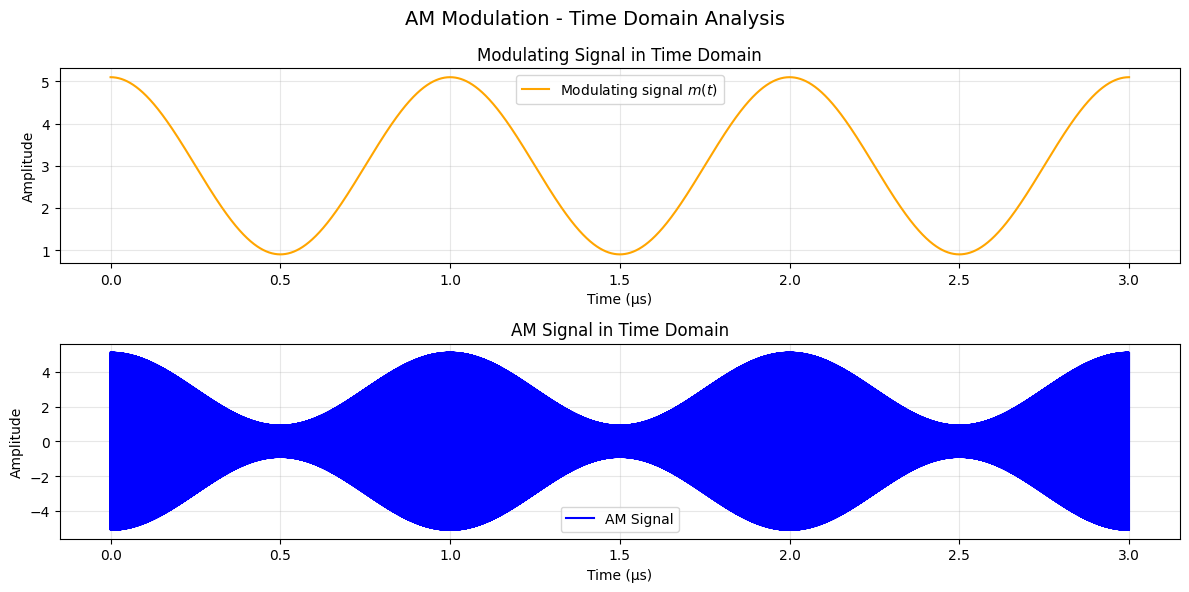

In [510]:
signals = [ {
            'data': m,
            'label': 'Modulating signal $m(t)$',
            'color': 'orange',
            'title': 'Modulating Signal in Time Domain'
        },
        {
            'data': s_bp,
            'label': 'AM Signal',
            'color': 'blue',
            'title': 'AM Signal in Time Domain'
        }
    ]
plot_time_domain(t, signals, title="AM Modulation - Time Domain Analysis")


### Indicate the frequencies and amplitude of the carrier and sidelobes on your spectrum plot.

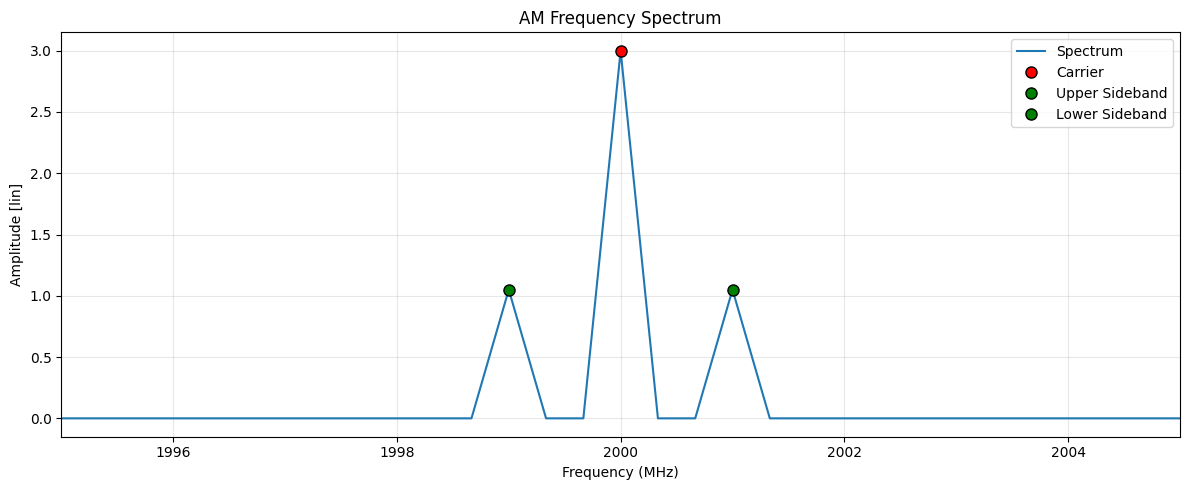

In [511]:
# --- FFT ---
N = len(t)
S = fft(s_bp)
f = fftfreq(N, 1/f_s)

# Keep only positive frequencies
f_pos = f[f > 0]
S_pos = 2 / N * np.abs(S[f > 0])  # Normalize amplitude


markers = [
        {'position': f_c, 'name': 'Carrier', 'color': 'red'},
        {'position': f_c + f_m, 'name': 'Upper Sideband', 'color': 'green'},
        {'position': f_c - f_m, 'name': 'Lower Sideband', 'color': 'green'}
    ]
plot_spectrum(f_pos, S_pos, title="AM Frequency Spectrum", markers=markers, xlim=(f_c-5e6, f_c+5e6))

### What is the modulation index? Show all necessary calculations.

In [512]:
A_m = 2.1
A_c = 3
mu = A_m / A_c
print(f"Modulation index (μ): {mu:.2f}")

Modulation index (μ): 0.70


### What are the frequencies of the upper and lower sidebands?

We expect the frequency of the sideband at 
$$f_{SB} = f_c \pm f_m$$

In [513]:
carrier_idx = np.argmin(np.abs(f_pos - f_c))
usb_idx = np.argmin(np.abs(f_pos - (f_c + f_m)))
lsb_idx = np.argmin(np.abs(f_pos - (f_c - f_m)))

carrier_freq = f_pos[carrier_idx]
usb_freq = f_pos[usb_idx]
lsb_freq = f_pos[lsb_idx]

print(f"Expected Carrier: {f_c/1e6:.2f} MHz, FFT Peak at: {carrier_freq/1e6:.2f} MHz")
print(f"Expected USB: {f_c/1e6 + f_m/1e6:.2f} MHz, FFT Peak at: {usb_freq/1e6:.2f} MHz")
print(f"Expected LSB: {f_c/1e6 - f_m/1e6:.2f} MHz, FFT Peak at: {lsb_freq/1e6:.2f} MHz")


Expected Carrier: 2000.00 MHz, FFT Peak at: 2000.00 MHz
Expected USB: 2001.00 MHz, FFT Peak at: 2001.00 MHz
Expected LSB: 1999.00 MHz, FFT Peak at: 1999.00 MHz


### What is the difference in amplitude (in dB) between the carrier and sidebands? Show all necessary calculations

In [514]:
carrier_amp = S_pos[carrier_idx]
sideband_amp = S_pos[usb_idx]

diff_dB = 20 * np.log10(carrier_amp / sideband_amp)
print(f"Carrier vs Sideband amplitude difference: {diff_dB:.2f} dB")

Carrier vs Sideband amplitude difference: 9.12 dB


## Task 2

In [515]:
f_c         = 2e9       # [Hz]
f_m         = 60e6      # [Hz]
mod_index   = 8         # [ ] 

t_max       = 33e-9     # [s]

In [516]:
t = np.arange(0, t_max, 1/f_s)

s_mod = np.sin(2 * np.pi * f_m * t)
s_bp  = np.cos(2 * np.pi * f_c * t + mod_index * s_mod)

### Show both the modulating signal and the modulated signal in time domain

Below in the lower plot it is cleary visible how the frequency changes based on the modulated signal from above.

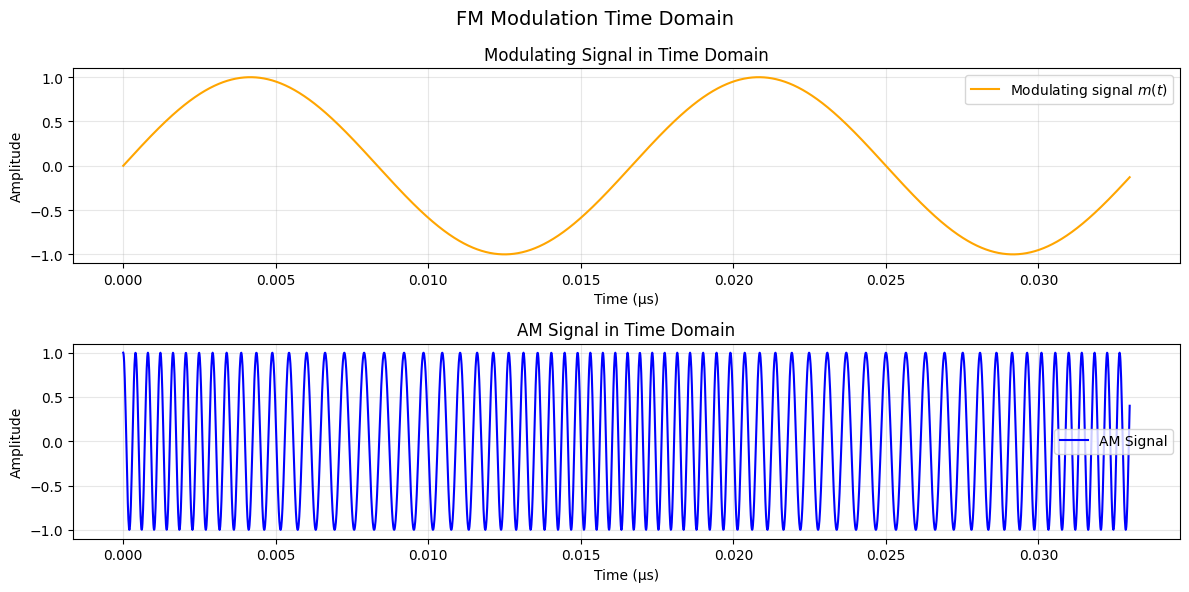

In [517]:
signals = [ {
            'data': s_mod,
            'label': 'Modulating signal $m(t)$',
            'color': 'orange',
            'title': 'Modulating Signal in Time Domain'
        },
        {
            'data': s_bp,
            'label': 'AM Signal',
            'color': 'blue',
            'title': 'AM Signal in Time Domain'
        }
    ]

plot_time_domain(t, signals, title="FM Modulation Time Domain")

In [518]:
s_mod = np.sin(2 * np.pi * f_m * t)
s_bp  = np.cos(2 * np.pi * f_c * t + mod_index * s_mod)

# --- FFT ---
N = len(t)
S = fft(s_bp)
f = fftfreq(N, 1/f_s)

# Keep only positive frequencies
f_pos = f[f > 0]
S_pos = 2 / N * np.abs(S[f > 0])  # Normalize amplitude

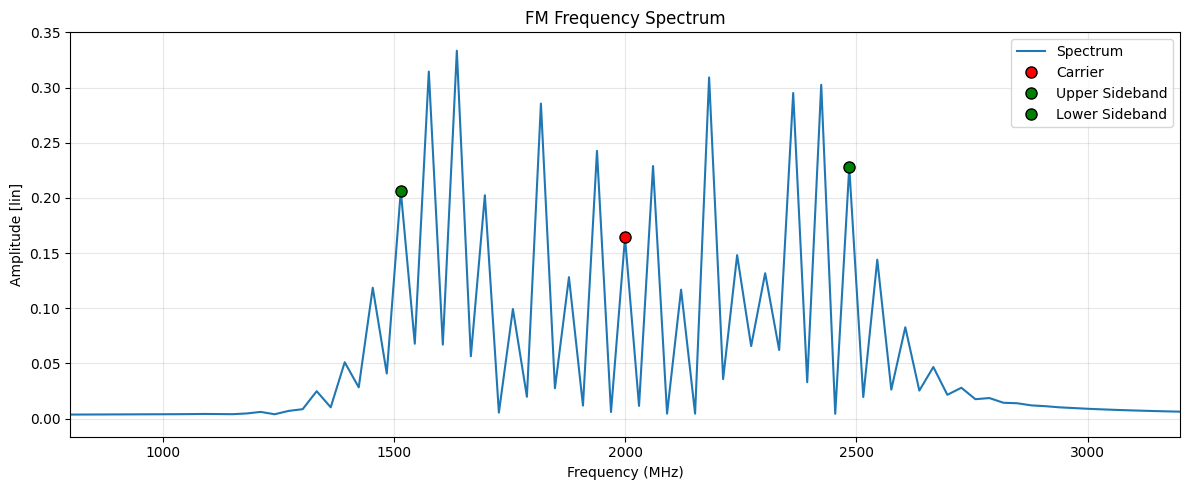

Simulated BW: 960.00 MHz


In [519]:
markers = [
        {'position': f_c, 'name': 'Carrier', 'color': 'red'},
        {'position': f_c + mod_index * f_m, 'name': 'Upper Sideband', 'color': 'green'},
        {'position': f_c - mod_index * f_m, 'name': 'Lower Sideband', 'color': 'green'}
    ]
plot_spectrum(f_pos, S_pos, title="FM Frequency Spectrum", markers=markers, xlim=(f_c - 20 * f_m, f_c + 20 * f_m))
print(f"Simulated BW: {((2 * mod_index * f_m)/1e6):.2f} MHz")


#### 3.2.2 For the same FM signal as in question 1, change 𝛽 to 0.1. Plot the spectrum. Indicate the frequencies and amplitude of the carrier and sidebands on your spectrum plot.

In [520]:
mod_index = 0.1 
s_mod = np.sin(2 * np.pi * f_m * t)
s_bp  = np.cos(2 * np.pi * f_c * t + mod_index * s_mod)

# --- FFT ---
N = len(t)
S = fft(s_bp)
f = fftfreq(N, 1/f_s)

# Keep only positive frequencies
f_pos = f[f > 0]
S_pos = 2 / N * np.abs(S[f > 0])  # Normalize amplitude


Simulated BW: 12.00 MHz


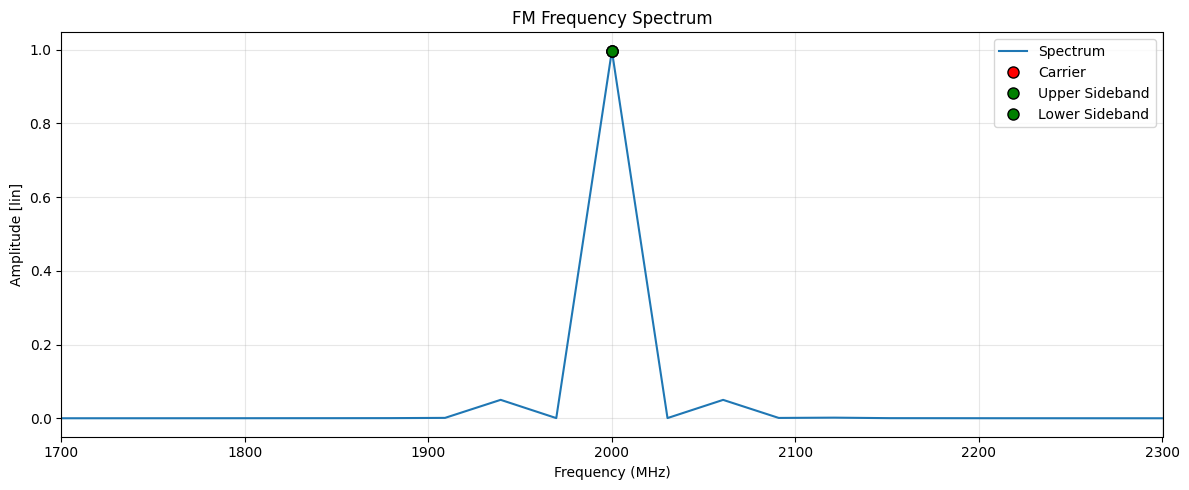

In [521]:
markers = [
        {'position': f_c, 'name': 'Carrier', 'color': 'red'},
        {'position': f_c + mod_index * f_m, 'name': 'Upper Sideband', 'color': 'green'},
        {'position': f_c - mod_index * f_m, 'name': 'Lower Sideband', 'color': 'green'}
    ]
print(f"Simulated BW: {((2 * mod_index * f_m)/1e6):.2f} MHz")

plot_spectrum(f_pos, S_pos, title="FM Frequency Spectrum", markers=markers, xlim=(f_c - 5 * f_m, f_c + 5 * f_m))

#### For the same FM signal as in question 1, now change 𝛽 to 20. Plot the spectrum

In [522]:
mod_index = 20 
s_mod = np.sin(2 * np.pi * f_m * t)
s_bp  = np.cos(2 * np.pi * f_c * t + mod_index * s_mod)

# --- FFT ---
N = len(t)
S = fft(s_bp)
f = fftfreq(N, 1/f_s)

# Keep only positive frequencies
f_pos = f[f > 0]
S_pos = 2 / N * np.abs(S[f > 0])  # Normalize amplitude


Simulated BW: 2400.00 MHz


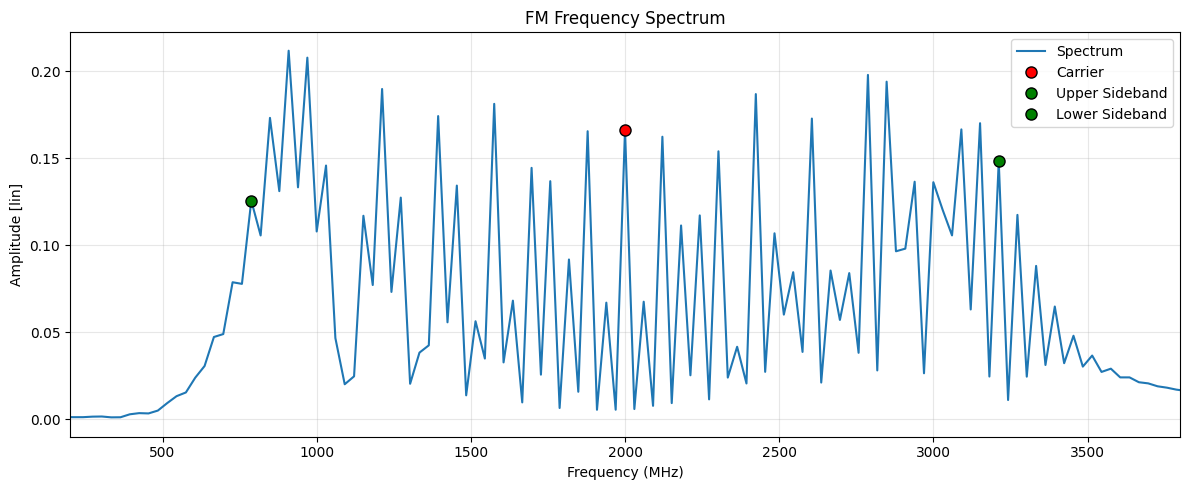

In [523]:
markers = [
        {'position': f_c, 'name': 'Carrier', 'color': 'red'},
        {'position': f_c + mod_index * f_m, 'name': 'Upper Sideband', 'color': 'green'},
        {'position': f_c - mod_index * f_m, 'name': 'Lower Sideband', 'color': 'green'}
    ]

print(f"Simulated BW: {((2 * mod_index * f_m)/1e6):.2f} MHz")
plot_spectrum(f_pos, S_pos, title="FM Frequency Spectrum", markers=markers, xlim=(f_c - 30 * f_m, f_c + 30 * f_m))

### 3.2.4 Complete the following table

**Calculation of $\Delta f$ and $BW_{theo}$**

In [524]:
b = 0.1
print(f"For FM-Modulation index of {b}")
print(f" Delta f: {(b * f_m)/1e6} MHz")
print(f"Theoretical BW: {((2 * f_m * (b + 1))/1e6):.2f} MHz\n")

b = 8
print(f"For FM-Modulation index of {b}")
print(f" Delta f: {(b * f_m)/1e6} MHz")
print(f"Theoretical BW: {(2 * f_m * (b + 1))/1e6} MHz\n")


b = 20
print(f"For FM-Modulation index of {b}")
print(f" Delta f: {(b * f_m)/1e6} MHz")
print(f"Theoretical BW: {(2 * f_m * (b + 1))/1e6} MHz\n")


For FM-Modulation index of 0.1
 Delta f: 6.0 MHz
Theoretical BW: 132.00 MHz

For FM-Modulation index of 8
 Delta f: 480.0 MHz
Theoretical BW: 1080.0 MHz

For FM-Modulation index of 20
 Delta f: 1200.0 MHz
Theoretical BW: 2520.0 MHz



$$BW_{theo} = 2 f_{m} (\Beta + 1)$$

| Modulation Index (𝛽) | Type of FM        | Δ𝑓 [MHz] | Theoretical Bandwidth [MHz] | Simulated Bandwidth [MHz]                            |
|----------------------|-------------------|------------------|-----------------------------|----------------------------------|
| 0.1                  | Narrowband FM     |  6.0         | 132.0   | 12                |
| 8                    | Wideband FM       | 480.0        | 1080.0      | 960      |
| 20                   | Ultra-wideband FM | 1200.0       | 2520.0     | 2400   |


Note: For calculating the simulated $BW$, we used the position of the green sideband markers.

#### 3.2.5 For the same FM signal as in question 1, change 𝛽 to 1 and then to 2.4

Simulated BW: 120.00 MHz


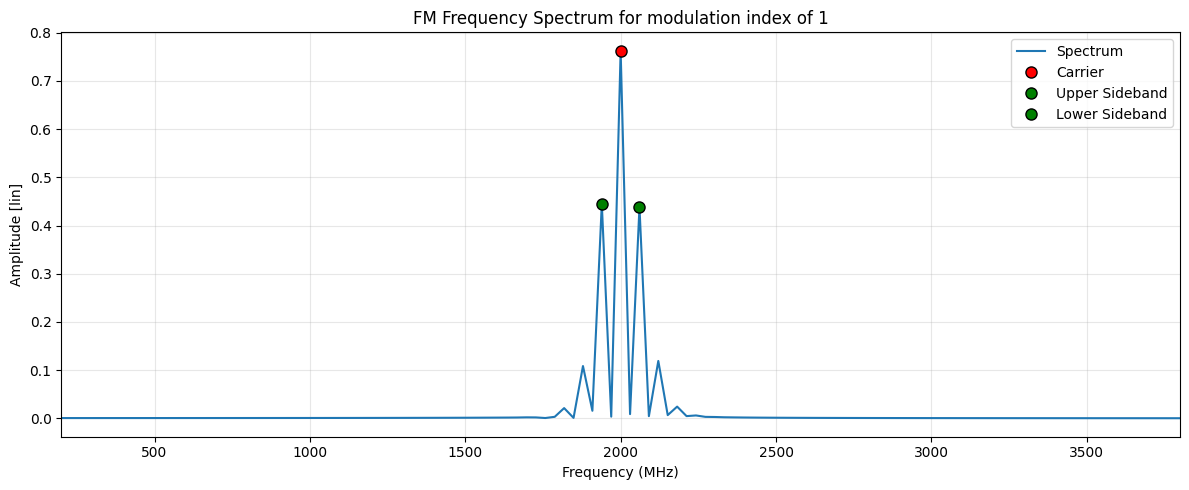

In [527]:
mod_index = 1
s_mod = np.sin(2 * np.pi * f_m * t)
s_bp  = np.cos(2 * np.pi * f_c * t + mod_index * s_mod)

# --- FFT ---
N = len(t)
S = fft(s_bp)
f = fftfreq(N, 1/f_s)

# Keep only positive frequencies
f_pos = f[f > 0]
S_pos = 2 / N * np.abs(S[f > 0])  # Normalize amplitude
markers = [
        {'position': f_c, 'name': 'Carrier', 'color': 'red'},
        {'position': f_c + mod_index * f_m, 'name': 'Upper Sideband', 'color': 'green'},
        {'position': f_c - mod_index * f_m, 'name': 'Lower Sideband', 'color': 'green'}
    ]

print(f"Simulated BW: {((2 * mod_index * f_m)/1e6):.2f} MHz")
plot_spectrum(f_pos, S_pos, title=f"FM Frequency Spectrum for modulation index of 1", markers=markers, xlim=(f_c - 30 * f_m, f_c + 30 * f_m))


Simulated BW: 288.00 MHz


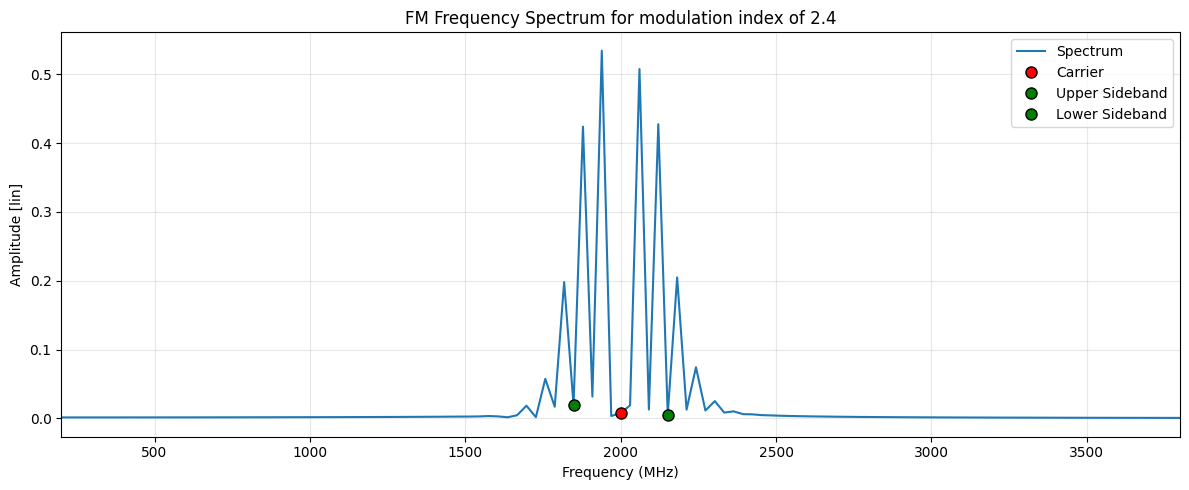

In [528]:
mod_index = 2.4
s_mod = np.sin(2 * np.pi * f_m * t)
s_bp  = np.cos(2 * np.pi * f_c * t + mod_index * s_mod)

# --- FFT ---
N = len(t)
S = fft(s_bp)
f = fftfreq(N, 1/f_s)

# Keep only positive frequencies
f_pos = f[f > 0]
S_pos = 2 / N * np.abs(S[f > 0])  # Normalize amplitude
markers = [
        {'position': f_c, 'name': 'Carrier', 'color': 'red'},
        {'position': f_c + mod_index * f_m, 'name': 'Upper Sideband', 'color': 'green'},
        {'position': f_c - mod_index * f_m, 'name': 'Lower Sideband', 'color': 'green'}
    ]

print(f"Simulated BW: {((2 * mod_index * f_m)/1e6):.2f} MHz")
plot_spectrum(f_pos, S_pos, title=f"FM Frequency Spectrum for modulation index of 2.4", markers=markers, xlim=(f_c - 30 * f_m, f_c + 30 * f_m))
